In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score, precision_score 
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("Lung Cancer Dataset.csv")
df.head()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,LUNG_CANCER
0,68,1,1,1,1,1,0,57.831178,0,0,1,1,95.977287,1,0,0,0,NO
1,81,1,1,0,0,1,1,47.694835,1,1,0,1,97.184483,0,0,0,0,YES
2,58,1,1,0,0,0,0,59.577435,0,1,1,0,94.974939,0,0,0,0,NO
3,44,0,1,0,1,1,0,59.785767,0,1,0,1,95.187900,0,0,0,0,YES
4,72,0,1,1,1,1,1,59.733941,0,1,0,1,93.503008,0,0,0,0,YES


In [3]:
df.shape

(5000, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   AGE                     5000 non-null   int64  
 1   GENDER                  5000 non-null   int64  
 2   SMOKING                 5000 non-null   int64  
 3   FINGER_DISCOLORATION    5000 non-null   int64  
 4   MENTAL_STRESS           5000 non-null   int64  
 5   EXPOSURE_TO_POLLUTION   5000 non-null   int64  
 6   LONG_TERM_ILLNESS       5000 non-null   int64  
 7   ENERGY_LEVEL            5000 non-null   float64
 8   IMMUNE_WEAKNESS         5000 non-null   int64  
 9   BREATHING_ISSUE         5000 non-null   int64  
 10  ALCOHOL_CONSUMPTION     5000 non-null   int64  
 11  THROAT_DISCOMFORT       5000 non-null   int64  
 12  OXYGEN_SATURATION       5000 non-null   float64
 13  CHEST_TIGHTNESS         5000 non-null   int64  
 14  FAMILY_HISTORY          5000 non-null   

In [5]:
df.describe()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE
count,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,57.222800,0.501200,0.666400,0.6012,0.539800,0.516000,0.439200,55.032043,0.394800,0.80040,0.354200,0.698200,94.991029,0.600600,0.301800,0.204000,0.209600
std,15.799224,0.500049,0.471546,0.4897,0.498463,0.499794,0.496339,7.913083,0.488857,0.39974,0.478318,0.459085,1.481048,0.489824,0.459085,0.403009,0.407064
min,30.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,23.258308,0.000000,0.00000,0.000000,0.000000,89.923133,0.000000,0.000000,0.000000,0.000000
25%,44.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,49.440685,0.000000,1.00000,0.000000,0.000000,93.973176,0.000000,0.000000,0.000000,0.000000
50%,57.000000,1.000000,1.000000,1.0000,1.000000,1.000000,0.000000,55.050421,0.000000,1.00000,0.000000,1.000000,94.974073,1.000000,0.000000,0.000000,0.000000
75%,71.000000,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,60.323320,1.000000,1.00000,1.000000,1.000000,95.989272,1.000000,1.000000,0.000000,0.000000
max,84.000000,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,83.046971,1.000000,1.00000,1.000000,1.000000,99.795786,1.000000,1.000000,1.000000,1.000000


In [6]:
df.isnull().sum()

AGE                       0
GENDER                    0
SMOKING                   0
FINGER_DISCOLORATION      0
MENTAL_STRESS             0
EXPOSURE_TO_POLLUTION     0
LONG_TERM_ILLNESS         0
ENERGY_LEVEL              0
IMMUNE_WEAKNESS           0
BREATHING_ISSUE           0
ALCOHOL_CONSUMPTION       0
THROAT_DISCOMFORT         0
OXYGEN_SATURATION         0
CHEST_TIGHTNESS           0
FAMILY_HISTORY            0
SMOKING_FAMILY_HISTORY    0
STRESS_IMMUNE             0
LUNG_CANCER               0
dtype: int64

In [7]:
df['LUNG_CANCER'].value_counts(normalize=True)*100

LUNG_CANCER
NO     59.26
YES    40.74
Name: proportion, dtype: float64

In [8]:
le = LabelEncoder()

df["LUNG_CANCER"] = le.fit_transform(df["LUNG_CANCER"])
df

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,LUNG_CANCER
0,68,1,1,1,1,1,0,57.831178,0,0,1,1,95.977287,1,0,0,0,0
1,81,1,1,0,0,1,1,47.694835,1,1,0,1,97.184483,0,0,0,0,1
2,58,1,1,0,0,0,0,59.577435,0,1,1,0,94.974939,0,0,0,0,0
3,44,0,1,0,1,1,0,59.785767,0,1,0,1,95.187900,0,0,0,0,1
4,72,0,1,1,1,1,1,59.733941,0,1,0,1,93.503008,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,32,0,1,1,0,0,1,60.700696,1,1,1,1,94.012495,0,1,1,0,1
4996,80,0,1,1,1,1,1,50.751741,0,1,1,1,94.394968,0,0,0,0,1
4997,51,1,0,0,1,0,0,61.063496,1,0,0,0,98.108901,0,0,0,1,0
4998,76,1,0,1,0,0,0,48.662872,0,1,0,1,95.577773,1,0,0,0,0


In [9]:
X = df.drop('LUNG_CANCER', axis=1)
y = df['LUNG_CANCER']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train

array([[ 0.37935754,  0.99700449,  0.71414549, ...,  1.52480188,
         1.98758523,  1.94985147],
       [ 0.82386756,  0.99700449,  0.71414549, ..., -0.6558229 ,
        -0.50312308, -0.51285958],
       [ 0.18885325, -1.00300451,  0.71414549, ..., -0.6558229 ,
        -0.50312308,  1.94985147],
       ...,
       [ 1.14137471,  0.99700449, -1.4002749 , ..., -0.6558229 ,
        -0.50312308, -0.51285958],
       [-0.89067106,  0.99700449, -1.4002749 , ..., -0.6558229 ,
        -0.50312308, -0.51285958],
       [-0.63666534,  0.99700449,  0.71414549, ..., -0.6558229 ,
        -0.50312308, -0.51285958]])

LOGISTIC REGRESSION

In [12]:
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

LogisticRegression()

In [13]:
y_pred_lr = model_lr.predict(X_test)

Accuracy: 91.0 %
Precision: 0.8808988764044944
Recall: 0.9137529137529138
F1  Score: 0.897025171624714


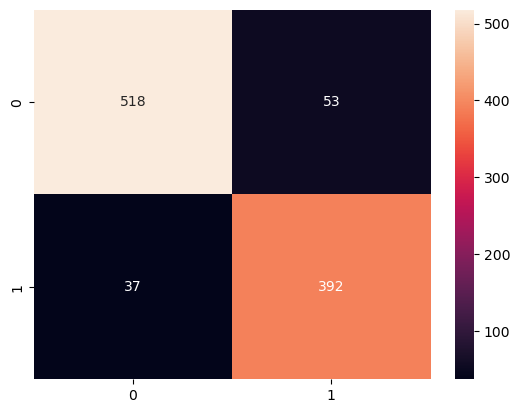

In [14]:
cm_lr=confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr,annot=True,fmt='g')
print("Accuracy:", accuracy_score(y_test, y_pred_lr) * 100, "%")
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1  Score:", f1_score(y_test, y_pred_lr))

KNN

In [15]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train,y_train)

KNeighborsClassifier()

In [23]:
y_pred_knn = model_knn.predict(X_test)

Accuracy: 87.1 %
Precision: 0.831858407079646
Recall: 0.8764568764568764
F1  Score: 0.8535754824063564


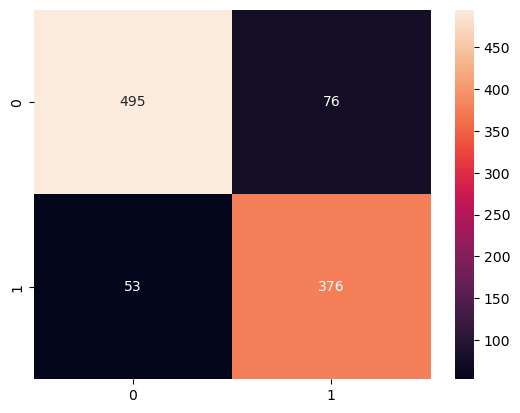

In [17]:
cm_knn=confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn,annot=True,fmt='g')
print("Accuracy:", accuracy_score(y_test, y_pred_knn) * 100, "%")
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1  Score:", f1_score(y_test, y_pred_knn))

SVM

In [18]:
model_svm = LinearSVC()
model_svm.fit(X_train,y_train)

LinearSVC()

In [19]:
y_pred_svm = model_svm.predict(X_test)

Accuracy: 90.60000000000001 %
Precision: 0.8730512249443207
Recall: 0.9137529137529138
F1  Score: 0.8929384965831435


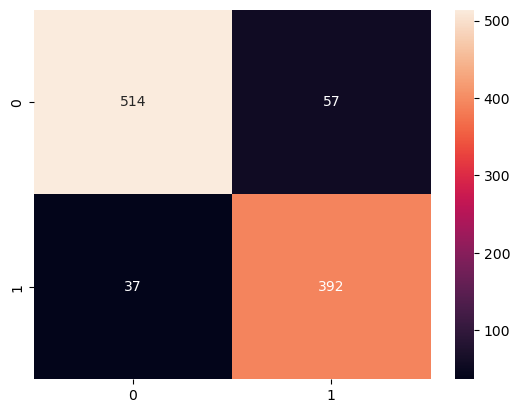

In [20]:
cm_svm=confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm,annot=True,fmt='g')
print("Accuracy:", accuracy_score(y_test, y_pred_svm) * 100, "%")
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1  Score:", f1_score(y_test, y_pred_svm))

MODEL COMPARISON

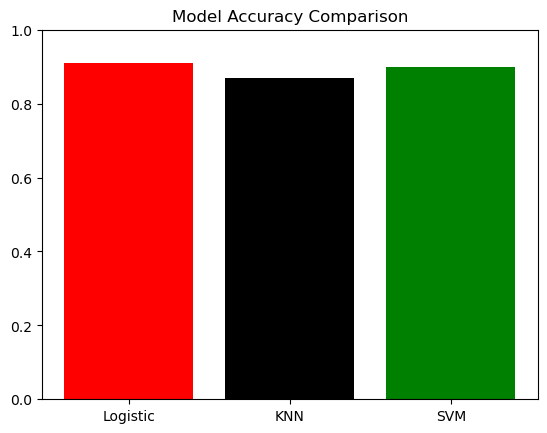

In [21]:
models = ['Logistic', 'KNN','SVM']
scores = [0.91, 0.87, 0.90]

plt.bar(models, scores, color=['red','black','green'])
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()

In [22]:
import pickle

pickle.dump(model_lr, open("logistic.pkl", "wb"))
pickle.dump(model_knn, open("knn.pkl", "wb"))
pickle.dump(model_svm, open("svm.pkl", "wb"))

In [24]:
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [25]:
accuracy_dict = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "KNN": accuracy_score(y_test, y_pred_knn)
}

pickle.dump(accuracy_dict, open("accuracy.pkl", "wb"))